# Практическая работа: EDA и модель для прогнозирования оттока клиентов

**Датасет:** Telco Customer Churn  
**Задача:** предсказать, уйдет ли клиент из телеком-компании (`Churn`).  

В этой работе нужно пройти полный ML-пайплайн:

1. загрузка данных;
2. первичный анализ;
3. обработка численных и категориальных признаков;
4. анализ целевой переменной;
5. EDA;
6. построение признаков;
7. обучение нескольких моделей;
8. оценка качества.

Датасет специально выбран так, чтобы в нем были:

- численные признаки;
- категориальные признаки;
- пропуски, спрятанные в текстовом столбце;
- несбалансированная целевая переменная;
- признаки, которые требуют анализа перед обучением модели.


## Описание датасета и признаков

В этой практике используется датасет **Telco Customer Churn**. В нем собрана информация о клиентах телеком-компании. Для каждого клиента известны демографические данные, подключенные услуги, тип контракта, способ оплаты и финансовые показатели.

**Целевая переменная:** `Churn`.

- `Churn = Yes` — клиент ушел из компании.
- `Churn = No` — клиент остался.

Задача модели — по признакам клиента предсказать вероятность оттока.

### Основные группы признаков

| Группа | Признаки | Что означают |
|---|---|---|
| Идентификатор | `customerID` | Уникальный номер клиента. Для модели обычно не нужен. |
| Демография | `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Пол, пожилой клиент или нет, есть ли партнёр, есть ли иждивенцы. |
| Длительность обслуживания | `tenure` | Сколько месяцев клиент пользуется услугами компании. |
| Телефонные услуги | `PhoneService`, `MultipleLines` | Есть ли телефонная связь и несколько линий. |
| Интернет | `InternetService` | Тип интернет-услуги: DSL, Fiber optic или нет интернета. |
| Дополнительные сервисы | `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Подключены ли дополнительные услуги. |
| Контракт и оплата | `Contract`, `PaperlessBilling`, `PaymentMethod` | Тип контракта, электронный счёт, способ оплаты. |
| Финансы | `MonthlyCharges`, `TotalCharges` | Ежемесячная оплата и общая сумма оплаты за всё время. |
| Target | `Churn` | Ушёл клиент или нет. |



## 1. Импорт библиотек

Импортируйте основные библиотеки для работы с данными, визуализации и машинного обучения.

Нужны как минимум:

- `pandas`, `numpy`;
- `matplotlib`, `seaborn`;
- инструменты из `sklearn` для train/test split, preprocessing, pipeline, моделей и метрик.


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV

## 2. Загрузка датасета

Загрузите данные по ссылке ниже в переменную `df`.

```python
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
```

После загрузки выведите первые 5 строк датасета.


In [22]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Первые 5 строк датасета:")
print(df.head())

Первые 5 строк датасета:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMo

## 3. Первичное знакомство с данными

Выведите:

1. размер датасета;
2. названия столбцов;
3. информацию о типах данных;
4. базовую статистику по численным признакам;
5. базовую статистику по категориальным признакам.

**Вопрос:** какие признаки кажутся численными, но имеют тип `object`?


In [23]:
print(f"\n1. Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

print(f"\n2. Названия столбцов:")
print(df.columns.tolist())

print(f"\n3. Типы данных:")
print(df.dtypes)

print(f"\n4. Базовая статистика по численным признакам:")
print(df.describe())

print(f"\n5. Базовая статистика по категориальным признакам:")
categorical_cols = df.select_dtypes(include=['object']).columns
print(df[categorical_cols].describe())


1. Размер датасета: 7043 строк, 21 столбцов

2. Названия столбцов:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

3. Типы данных:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dty

Признак 'TotalCharges' кажется численным, но имеет тип object, так как в этом столбце некоторые значения записаны как пробелы, а это мешает pandas автоматически определить его как числовой тип.

## 4. Проверка пропусков и неявных ошибок

Проверьте количество пропусков в каждом столбце.

Затем внимательно изучите столбец `TotalCharges`. Он должен быть численным, но часто в этом датасете он загружается как текст.

Найдите строки, где `TotalCharges` нельзя корректно преобразовать в число.


In [24]:
print("Пропуски в каждом столбце:")
print(df.isnull().sum())

invalid_rows = df[~df['TotalCharges'].str.replace('.', '', regex=False).str.isdigit()]
print(f"\nКоличество некорректных строк в TotalCharges: {len(invalid_rows)}")
print(invalid_rows[['customerID', 'TotalCharges']])

Пропуски в каждом столбце:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Количество некорректных строк в TotalCharges: 11
      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             
3331  7644-OMVMY             
3826  3213-VVOLG             
4380  2520-SGTTA             
5218  2923-ARZLG             
6670  4075-WKNIU             
6754  2775-SEFEE             


## 5. Очистка данных

Сделайте следующие шаги:

1. преобразуйте `TotalCharges` в численный тип;
2. удалите или обработайте строки, где `TotalCharges` стал пропуском;
3. удалите столбец `customerID`, потому что это идентификатор, а не полезный признак;
4. проверьте результат.


In [25]:
#TotalCharges в численный тип
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"После преобразования пропусков в TotalCharges: {df['TotalCharges'].isnull().sum()}")

#Удаляем строки
df = df.dropna(subset=['TotalCharges'])

print(f"После удаления строк с пропусками осталось строк: {len(df)}")

#Удаляем столбец customerID
df = df.drop('customerID', axis=1)

print("\nИтог:")
print(f"Тип данных TotalCharges: {df['TotalCharges'].dtype}")
print(f"Пропуски в TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Итоговый размер датасета: {df.shape}")

После преобразования пропусков в TotalCharges: 11
После удаления строк с пропусками осталось строк: 7032

Итог:
Тип данных TotalCharges: float64
Пропуски в TotalCharges: 0
Итоговый размер датасета: (7032, 20)


## 6. Анализ целевой переменной

Проанализируйте столбец `Churn`.

Нужно:

1. вывести количество объектов каждого класса;
2. вывести долю объектов каждого класса;
3. построить график распределения целевой переменной;
4. сделать короткий вывод: сбалансирована ли задача?



1. Количество объектов каждого класса:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

2. Доля объектов каждого класса (%):
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


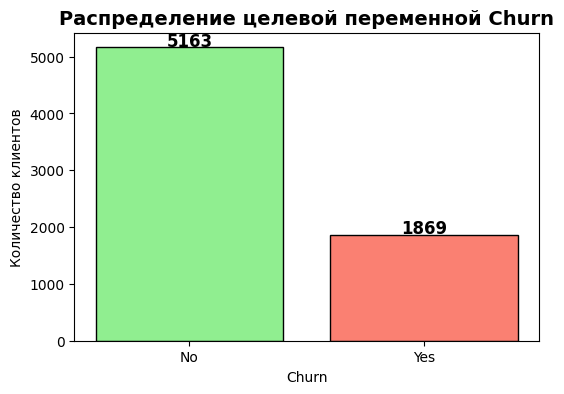

In [26]:
print("\n1. Количество объектов каждого класса:")
print(df['Churn'].value_counts())

print("\n2. Доля объектов каждого класса (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

counts = df['Churn'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=['lightgreen', 'salmon'], edgecolor='black')
plt.title('Распределение целевой переменной Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Количество клиентов')

for i, val in enumerate(counts.values):
    plt.text(i, val + 20, str(val), ha='center', fontsize=12, fontweight='bold')

plt.show()


Задача не сбалансирована. Клиенты, которые не ушли: 5163, клиенты, которые ушли: 1869. Требуется учитывать этот дисбаланс классов при обучении модели.

## 7. EDA численных признаков

Найдите все численные признаки и постройте для них гистограммы.

После этого ответьте:

- какие признаки имеют асимметричное распределение?
- есть ли признаки с большим разбросом значений?


Численные признаки: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


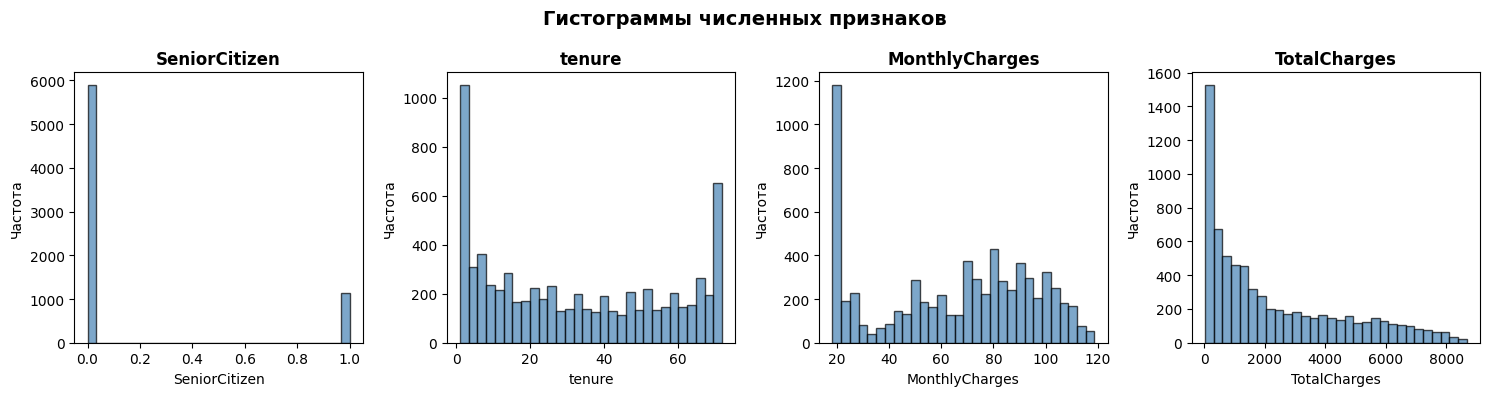


Статистика численных признаков:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1.000000    72.000000      118.750000   8684.800000

Признаки с асимметричным распределением:
   - SeniorCitizen: асимметрия = 1.83
   - TotalCharges: асимметрия = 0.96

Признаки с большим разбросом значений (коэф. > 0.5):
   - SeniorCitizen: коэффициент вариации = 2.27
   - tenure: коэффициент вариации = 0.76
   - TotalCharges: коэффициент вариации = 0.99


In [29]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Численные признаки: {numeric_features}")

fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 4))
if len(numeric_features) == 1:
    axes = [axes]

for i, feature in enumerate(numeric_features):
    axes[i].hist(df[feature], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Частота')

plt.suptitle('Гистограммы численных признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nСтатистика численных признаков:")
print(df[numeric_features].describe())

print("\nПризнаки с асимметричным распределением:")
for feature in numeric_features:
    skewness = df[feature].skew()
    if abs(skewness) > 0.5:
        print(f"   - {feature}: асимметрия = {skewness:.2f}")

print("\nПризнаки с большим разбросом значений (коэф. > 0.5):")
for feature in numeric_features:
    cv = df[feature].std() / df[feature].mean()
    if cv > 0.5:
        print(f"   - {feature}: коэффициент вариации = {cv:.2f}")

## 8. Связь численных признаков с целевой переменной

Для каждого численного признака постройте boxplot относительно `Churn`.

Ответьте:

- отличаются ли клиенты с `Churn = Yes` и `Churn = No`?
- какие численные признаки выглядят наиболее полезными?


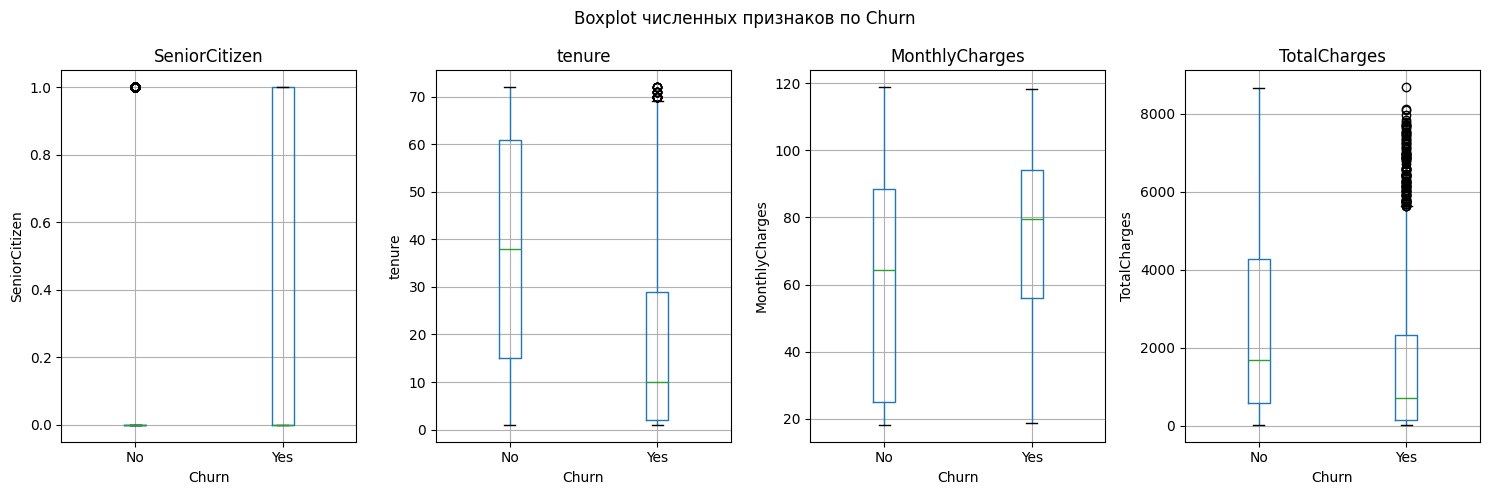

In [30]:
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 5))
if len(numeric_features) == 1:
    axes = [axes]

for i, feature in enumerate(numeric_features):
    df.boxplot(column=feature, by='Churn', ax=axes[i])
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(feature)

plt.suptitle('Boxplot численных признаков по Churn')
plt.tight_layout()
plt.show()

клиенты с Churn = Yes и Churn = No, отличаются. У клиентов Churn = Yes меньше tenure, меньше TotalCharges и примерно такой же MonthlyCharges

Наиболее позные: tenure и MonthlyCharges

## 9. EDA категориальных признаков

Найдите категориальные признаки.

Для каждого категориального признака выведите количество уникальных значений. Затем постройте countplot для нескольких наиболее интересных признаков.

Рекомендуемые признаки для графиков:

- `Contract`;
- `InternetService`;
- `PaymentMethod`;
- `OnlineSecurity`;
- `TechSupport`.


In [31]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('Churn')

print("Категориальные признаки и количество уникальных значений:")
for feat in categorical_features:
    print(f"  {feat}: {df[feat].nunique()}")

Категориальные признаки и количество уникальных значений:
  gender: 2
  Partner: 2
  Dependents: 2
  PhoneService: 2
  MultipleLines: 3
  InternetService: 3
  OnlineSecurity: 3
  OnlineBackup: 3
  DeviceProtection: 3
  TechSupport: 3
  StreamingTV: 3
  StreamingMovies: 3
  Contract: 3
  PaperlessBilling: 2
  PaymentMethod: 4


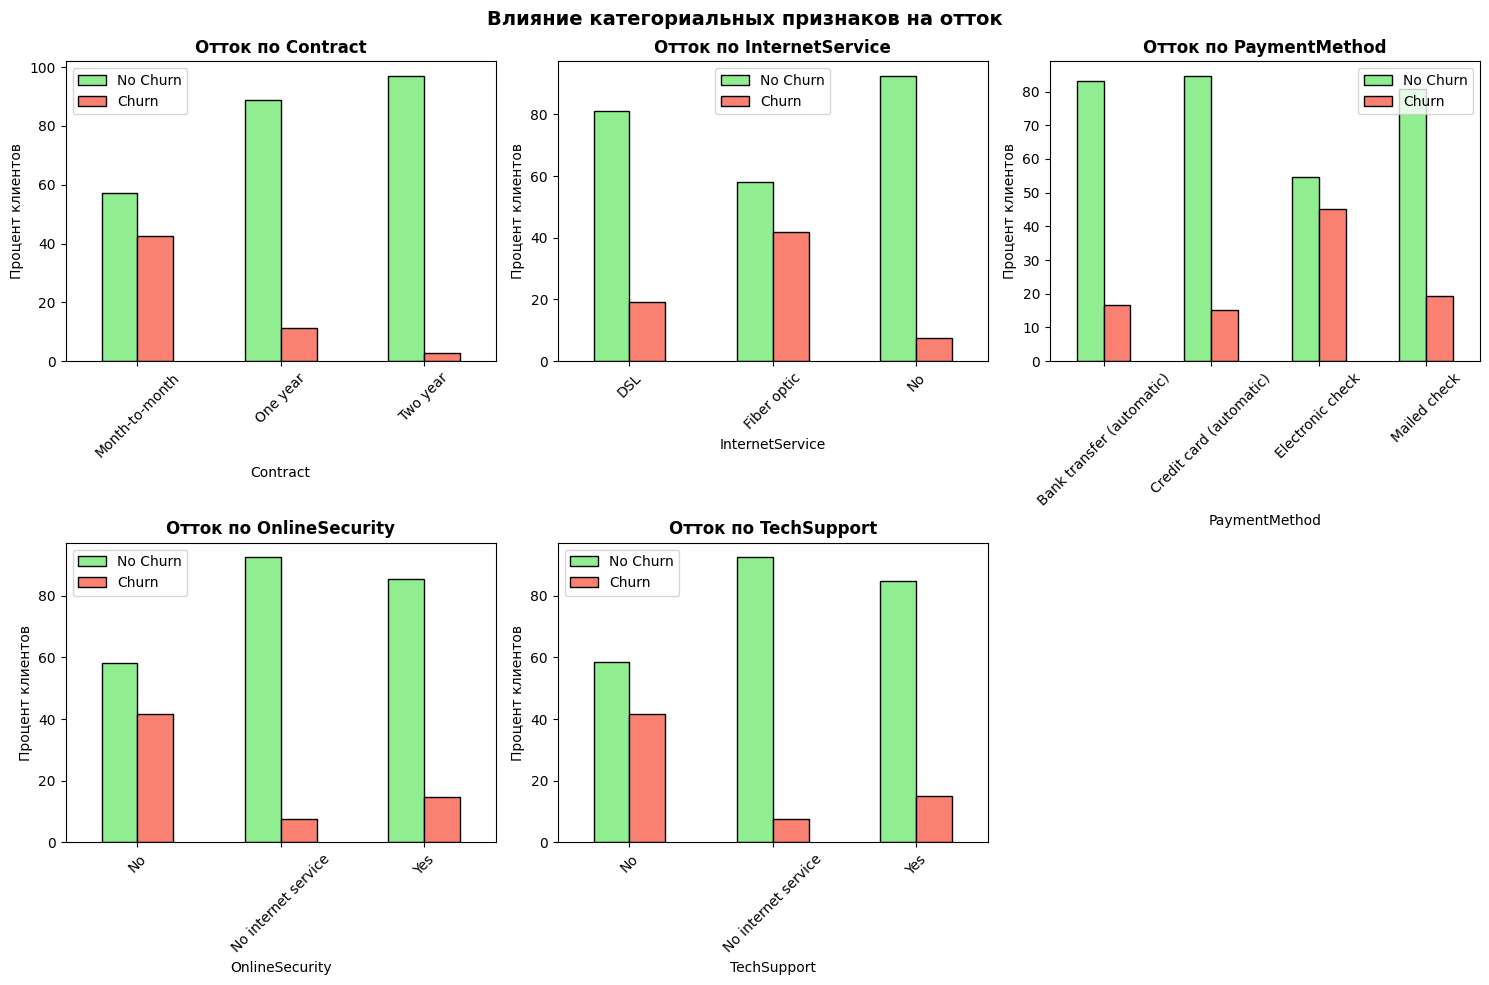

In [32]:
selected_features = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    churn_rate = pd.crosstab(df[feature], df['Churn'], normalize='index') * 100
    churn_rate.plot(kind='bar', ax=axes[i], color=['lightgreen', 'salmon'], edgecolor='black')
    axes[i].set_title(f'Отток по {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Процент клиентов')
    axes[i].legend(['No Churn', 'Churn'])
    axes[i].tick_params(axis='x', rotation=45)

plt.delaxes(axes[5])
plt.suptitle('Влияние категориальных признаков на отток', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Доля оттока по категориям

Для признаков `Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity`, `TechSupport` посчитайте долю клиентов с `Churn = Yes` внутри каждой категории.

Подсказка: удобно создать численную версию целевой переменной:

```python
df_clean['Churn_num'] = (df_clean['Churn'] == 'Yes').astype(int)
```


In [33]:
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

features = ['Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 'TechSupport']

for feature in features:
    print(f"\n{feature}:")
    print(df.groupby(feature)['Churn_num'].mean().sort_values(ascending=False) * 100)


Contract:
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn_num, dtype: float64

PaymentMethod:
PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn_num, dtype: float64

InternetService:
InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn_num, dtype: float64

OnlineSecurity:
OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: Churn_num, dtype: float64

TechSupport:
TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: Churn_num, dtype: float64


## 11. Корреляции численных признаков

Постройте корреляционную матрицу для численных признаков и `Churn_num`.

Ответьте:

- какие признаки сильнее всего связаны с оттоком?
- есть ли сильная корреляция между признаками?


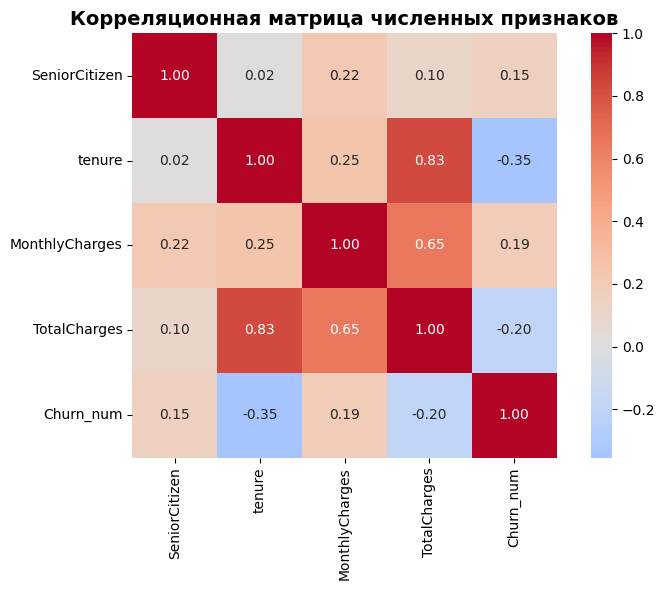

In [35]:
numeric_with_target = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr_matrix = df[numeric_with_target].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Корреляционная матрица численных признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

1.
- tenure (коэффициент корреляции -0,35) - это самый сильный признак. Отрицательная корреляция означает, что чем дольше клиент пользуется услугами компании, тем реже он уходит.
- TotalCharges (-0,20) - также имеет отрицательную связь: чем больше общая сумма платежей, тем ниже риск оттока.
- MonthlyCharges (+0,19) - положительная корреляция: клиенты с более высоким ежемесячным платежом уходят чаще.
- SeniorCitizen (+0,15) - слабая положительная связь: пожилые клиенты немного чаще уходят, но этот признак менее важен.

2. tenure и TotalCharges: 0.83

## 12. Простая генерация новых признаков

Создайте несколько новых признаков:

1. `tenure_group` — группа длительности пользования услугами;
2. `services_count` — количество подключенных дополнительных сервисов;
3. `avg_charge_per_month` — средняя сумма оплаты за месяц.

Подсказка для `services_count`: можно посчитать, сколько сервисных столбцов имеют значение `Yes`.


In [37]:
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24, 36, 48, 60, 72],
                            labels=['0-1 год', '1-2 года', '2-3 года',
                                   '3-4 года', '4-5 лет', '5-6 лет'])

service_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']
df['services_count'] = df[service_columns].apply(lambda x: (x == 'Yes').sum(), axis=1)

df['avg_charge_per_month'] = df['TotalCharges'] / df['tenure']
df['avg_charge_per_month'] = df['avg_charge_per_month'].replace([float('inf'), -float('inf')], 0)

print("Новые признаки:")
print(f"tenure_group: {df['tenure_group'].nunique()} категорий")
print(f"services_count: от {df['services_count'].min()} до {df['services_count'].max()}")
print(f"avg_charge_per_month: от {df['avg_charge_per_month'].min():.2f} до {df['avg_charge_per_month'].max():.2f}")

print("\nПервые 5 строк:")
print(df[['tenure', 'tenure_group', 'services_count', 'avg_charge_per_month']].head())

Новые признаки:
tenure_group: 6 категорий
services_count: от 0 до 6
avg_charge_per_month: от 13.78 до 121.40

Первые 5 строк:
   tenure tenure_group  services_count  avg_charge_per_month
0       1      0-1 год               1             29.850000
1      34     2-3 года               2             55.573529
2       2      0-1 год               2             54.075000
3      45     3-4 года               3             40.905556
4       2      0-1 год               0             75.825000


## 13. Подготовка признаков и разбиение данных

Сделайте:

1. `X` — все признаки, кроме `Churn`;
2. `y` — целевая переменная `Churn`, преобразованная в 0/1;
3. разбиение на train/test в пропорции 80/20;
4. используйте `stratify=y`, чтобы сохранить баланс классов.


In [39]:
X = df.drop(['Churn', 'Churn_num'], axis=1)
y = (df['Churn'] == 'Yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (5625, 22)
Размер тестовой выборки: (1407, 22)


## 14. Создание preprocessing pipeline

Создайте preprocessing pipeline:

Для численных признаков:

- заполнение пропусков медианой;
- масштабирование через `StandardScaler`.

Для категориальных признаков:

- заполнение пропусков самым частым значением;
- One-Hot Encoding.

Используйте `ColumnTransformer`.


In [43]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
                    'services_count', 'avg_charge_per_month']
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                        'PaperlessBilling', 'PaymentMethod', 'tenure_group']

#для численных
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#для категориальных
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 15. Обучение нескольких моделей

В этом задании нужно обучить и сравнить несколько моделей машинного обучения для задачи классификации клиентов по признаку `Churn`.

Обучите следующие модели:

- `LogisticRegression` — линейная модель для классификации;
- `DecisionTreeClassifier` — одно дерево решений;
- `SVC` — метод опорных векторов;
- `MLPClassifier` — простая нейронная сеть;
- `KNeighborsClassifier` — метод k ближайших соседей;
- `GaussianNB` — наивный байесовский классификатор;
- `RandomForestClassifier` — ансамбль деревьев решений;
- `ExtraTreesClassifier` — ансамбль случайных деревьев.

Каждую модель нужно обучать через `Pipeline`.

Структура pipeline должна быть следующей:

1. `preprocessing` — подготовка численных и категориальных признаков;
2. `classifier` — модель машинного обучения.

Для каждой модели:

1. создайте отдельный pipeline;
2. обучите модель на обучающей выборке;
3. сделайте предсказания на тестовой выборке;
4. сохраните результаты для дальнейшего сравнения.

In [47]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'SVC': SVC(random_state=42, probability=True),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=1000),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'ExtraTreesClassifier': ExtraTreesClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = y_pred

## 16. Оценка качества моделей

Создайте таблицу, где для каждой модели будут указаны основные метрики качества:

- `Accuracy`;
- `Precision`;
- `Recall`;
- `F1-score`;
- `ROC-AUC`.

Также выведите `classification_report`.

- какая модель показала лучший результат по `F1-score`;
- какая модель лучше находит клиентов, которые действительно уйдут;
- почему `Accuracy` может быть недостаточной метрикой для этой задачи.


In [51]:
metrics_list = []

for name, y_pred in results.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    metrics_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"\n{classification_report(y_test, y_pred, target_names=['No', 'Yes'])}")

metrics_df = pd.DataFrame(metrics_list)
print("сравнение моделей")
print(metrics_df.sort_values('F1-score', ascending=False))


              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1033
         Yes       0.64      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407


              precision    recall  f1-score   support

          No       0.80      0.79      0.79      1033
         Yes       0.44      0.47      0.45       374

    accuracy                           0.70      1407
   macro avg       0.62      0.63      0.62      1407
weighted avg       0.71      0.70      0.70      1407


              precision    recall  f1-score   support

          No       0.81      0.91      0.86      1033
         Yes       0.64      0.43      0.51       374

    accuracy                           0.78      1407
   macro avg       0.73      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407


              p

Лучший результат по F1-score показала LogisticRegression (0.58). Лучше всех находит ушедших клиентов GaussianNB (Recall 0.84), но у неё низкая Precision (0.43). Accuracy недостаточна, так как классы несбалансированы (74% клиентов не уходят), и модель, предсказывающая всем "No", получит 74% accuracy, но не найдёт ни одного ушедшего клиента.

## 17. Балансировка классов через oversampling

В задаче `Churn` классы несбалансированы: клиентов с `Churn = No` больше, чем клиентов с `Churn = Yes`.

Теперь попробуйте улучшить обучение с помощью **oversampling**.

Oversampling означает, что мы увеличиваем количество объектов меньшего класса в обучающей выборке. Важно: oversampling нужно делать **только на train**, а test должен остаться неизменным.

Сделайте следующие шаги:

1. объедините `X_train` и `y_train` в один DataFrame;
2. разделите train на majority class и minority class;
3. увеличьте minority class с помощью `sample(..., replace=True)`;
4. снова разделите данные на `X_train_over` и `y_train_over`;
5. проверьте новое распределение классов.


In [54]:
train_df = pd.concat([X_train, y_train], axis=1)

majority = train_df[train_df['Churn'] == 0]
minority = train_df[train_df['Churn'] == 1]

minority_oversampled = resample(minority,
                                replace=True,
                                n_samples=len(majority),
                                random_state=42)

train_oversampled = pd.concat([majority, minority_oversampled])

X_train_over = train_oversampled.drop('Churn', axis=1)
y_train_over = train_oversampled['Churn']

print("Распределение классов:")
print(y_train_over.value_counts())
print(f"\nПроценты: {y_train_over.value_counts(normalize=True) * 100}")

Распределение классов:
Churn
0    4130
1    4130
Name: count, dtype: int64

Проценты: Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


## 18. Обучение моделей после oversampling

В этом задании нужно повторить обучение моделей, но уже на сбалансированной обучающей выборке.

Используйте те же модели, что и в задании 15:

- `LogisticRegression`;
- `DecisionTreeClassifier`;
- `SVC`;
- `MLPClassifier`;
- `KNeighborsClassifier`;
- `GaussianNB`;
- `RandomForestClassifier`;
- `ExtraTreesClassifier`.

Затем оцените их на исходной test-выборке `X_test`, `y_test`.

Сравните результаты до и после oversampling.

**Вопросы:**

- увеличился ли Recall для класса `Churn = Yes`?
- изменился ли Precision?
- какая модель лучше после балансировки?
- стало ли качество лучше по F1-score?


In [58]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'SVC': SVC(random_state=42, probability=True),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=1000),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'ExtraTreesClassifier': ExtraTreesClassifier(random_state=42)
}

results_over = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train_over, y_train_over)
    y_pred = pipeline.predict(X_test)
    results_over[name] = y_pred

print("Сравнение результатов (до -> после oversampling):")

for name in results.keys():
    old_recall = metrics_df[metrics_df['Model'] == name]['Recall'].values[0]
    new_recall = recall_score(y_test, results_over[name])
    old_precision = metrics_df[metrics_df['Model'] == name]['Precision'].values[0]
    new_precision = precision_score(y_test, results_over[name])
    old_f1 = metrics_df[metrics_df['Model'] == name]['F1-score'].values[0]
    new_f1 = f1_score(y_test, results_over[name])

    print(f"\n{name}:")
    print(f"  Recall:    {old_recall:.3f} -> {new_recall:.3f}")
    print(f"  Precision: {old_precision:.3f} -> {new_precision:.3f}")
    print(f"  F1-score:  {old_f1:.3f} -> {new_f1:.3f}")

Сравнение результатов (до -> после oversampling):

LogisticRegression:
  Recall:    0.527 -> 0.778
  Precision: 0.638 -> 0.481
  F1-score:  0.577 -> 0.594

DecisionTreeClassifier:
  Recall:    0.468 -> 0.521
  Precision: 0.441 -> 0.510
  F1-score:  0.454 -> 0.516

SVC:
  Recall:    0.425 -> 0.791
  Precision: 0.639 -> 0.509
  F1-score:  0.510 -> 0.619

MLPClassifier:
  Recall:    0.484 -> 0.620
  Precision: 0.554 -> 0.501
  F1-score:  0.516 -> 0.554

KNeighborsClassifier:
  Recall:    0.537 -> 0.701
  Precision: 0.537 -> 0.446
  F1-score:  0.537 -> 0.545

GaussianNB:
  Recall:    0.837 -> 0.853
  Precision: 0.434 -> 0.428
  F1-score:  0.571 -> 0.570

RandomForestClassifier:
  Recall:    0.479 -> 0.567
  Precision: 0.615 -> 0.597
  F1-score:  0.538 -> 0.582

ExtraTreesClassifier:
  Recall:    0.489 -> 0.449
  Precision: 0.587 -> 0.602
  F1-score:  0.534 -> 0.515


1. Увеличился ли Recall для класса Churn = Yes?
Да, Recall увеличился у 7 из 8 моделей. Только у ExtraTreesClassifier Recall снизился с 0,489 до 0,449.

2. Изменился ли Precision?
Precision снизился у большинства моделей. LogisticRegression, KNeighborsClassifier, MLPClassifier, GaussianNB - упал. Небольшой рост Precision произошёл у DecisionTreeClassifier и ExtraTreesClassifier.

3. Какая модель лучше после балансировки?
Лучшей моделью после балансировки стал SVC с F1-score 0,619, за ним следует LogisticRegression с F1-score 0,594.

4. Стало ли качество лучше по F1-score?
F1-score улучшился у 6 из 8 моделей. Незначительное ухудшение произошло у GaussianNB (0,571 до 0,570) и ExtraTreesClassifier (0,534 до 0,515). В целом oversampling помог улучшить качество моделей.

## 19. Оптимизация гиперпараметров лучшей модели

В этом задании нужно выбрать лучшую модель из задания 18 и улучшить ее качество с помощью подбора гиперпараметров.

Сначала определите лучшую модель после oversampling.

Основной критерий выбора:

- `F1-score` для класса `Churn = Yes`.

Дополнительно можно учитывать:

- `Recall` для класса `Churn = Yes`;
- `Precision`;
- `ROC-AUC`

После выбора модели выполните подбор гиперпараметров с помощью `GridSearchCV` или `RandomizedSearchCV`.

Важно:

- финальную оценку нужно делать только на исходной test-выборке `X_test`, `y_test`.

Для оптимизации:

1. выберите сетку гиперпараметров для лучшей модели;
2. запустите `GridSearchCV` или `RandomizedSearchCV`;
3. найдите лучшие параметры;
4. обучите лучшую модель;
5. оцените ее на test-выборке;
6. сравните результат с моделью из задания 18 до оптимизации.

Метрики для финального сравнения:

- `Accuracy`;
- `Precision`;
- `Recall`;
- `F1-score`;
- `ROC-AUC`.

Вопросы для анализа:

- какие гиперпараметры оказались лучшими;
- улучшился ли `F1-score`;
- изменился ли баланс между `Precision` и `Recall`;
- стала ли модель лучше находить клиентов, которые могут уйти;
- не выглядит ли результат как переобучение;
- стоит ли использовать эту модель в реальной задаче удержания клиентов.

In [ ]:
best_model = SVC(random_state=42, probability=True)

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', best_model)])

param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_over, y_train_over)

print("Лучшие параметры:", grid_search.best_params_)

y_pred_best = grid_search.predict(X_test)
y_pred_proba_best = grid_search.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_best):.4f}")

print("\nСравнение с моделью до оптимизации (из задания 18):")
print(f"F1-score до: 0.619 -> после: {f1_score(y_test, y_pred_best):.4f}")

он проработал 7 минут и занятие закончилось(

## 20. Отбор важных признаков с помощью RandomForest и SelectFromModel

В этом задании нужно использовать `RandomForestClassifier` для отбора наиболее важных признаков, затем заново обучить лучшую оптимизированную модель из задания 19 только на выбранных признаках.

Цель задания — проверить, можно ли уменьшить количество признаков без сильной потери качества модели.

### Сравнение результатов

Сравните три варианта модели:

1. лучшая модель из задания 18 после `oversampling`;
2. оптимизированная модель из задания 19;
3. оптимизированная модель после отбора признаков через `SelectFromModel`.

Для сравнения используйте следующие метрики:

- `Accuracy`;
- `Precision`;
- `Recall`;
- `F1-score`;
- `ROC-AUC`.

Создайте итоговую таблицу с результатами всех трех вариантов.

Пример структуры таблицы:

| Model version | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Best model after oversampling |  |  |  |  |  |
| Optimized model |  |  |  |  |  |
| Optimized model + SelectFromModel |  |  |  |  |  |

Ответьте на вопросы:

- улучшилось ли качество после отбора признаков;
- уменьшилось ли количество признаков;
- изменился ли `Precision`;
- изменился ли `Recall` для класса `Churn = Yes`;
- изменился ли `F1-score`;
- стала ли модель проще;
- стоит ли использовать отбор признаков в финальном решении.